# Описательная статистика и визуализация

Содержание:
1. Импорты библиотек
2. Описание данных
3. Автоматические отчеты
4. Описание показателей
5. Визуализации


### 1. Импорты библиотек

In [ ]:
# pip install sweetviz
# !pip install jupyterlab
# pip install --upgrade nbformat

In [3]:
import pandas as pd
import numpy as np
import nbformat
# from ydata_profiling import ProfileReport
import sweetviz as sv
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import statistics
import scipy.stats as st
import plotly.express as px
 
from IPython.display import Image

In [4]:
# pip install plotly

In [5]:
## Автоматические библиотеки ProfileReport и sweetviz требуют разных версий numpy
# pip install numpy==1.23.5 ## для sweetviz, для ProfileReport - актуальная версия

#### Настройки вывода

In [6]:
# Показать все колонки
pd.set_option('display.max_columns', None)
# Установить ширину отображения
pd.set_option('display.width', None)
# Отобразить все колонки без сокращения
pd.set_option('display.expand_frame_repr', False)

### 2. Описание данных

In [7]:
# Исходный датафрейм
df = pd.read_csv('imdb_top_1000.csv')

In [21]:
df.head(1)

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Top_Genre
0,The Shawshank Redemption,1994,A,142,Drama,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469",Drama


Датасет с топ-1000 фильмов imdb

Параметры:
1) Poster_Link - ссылка на постер
2) Series_Title - название
3) Released_Year - год выхода
4) Certificate - возрастной рейтинг
5) Runtime - длительность
6) Genre - жанр
7) IMDB_Rating - рейтинг IMDB
8) Overview - описание
9) Meta_score - оценка Meta_score
10) Director - режиссер
11) Star1 - актер 1
12) Star2 - актер 2
13) Star3 - актер 3
14) Star4 - актер 4
15) No_of_Votes - число голосов
16) Gross - доход


In [9]:
df.info() ## получаем типы данных и число пропусков в колонках
df[df.isna().any(axis=1)] ## строки с пропусками
df.describe(include="all") ## описательная статистика для числовых столбов и частотность для категорий

## в данном df есть несоответствия в типах данных - приведем к верному
df['Runtime'] = df['Runtime'].str.replace(' min','').astype(int)
## удаляю столбы с ссылками и текстом - в рамках данного ноутбука они не нужны
df.drop(columns=['Poster_Link','Overview'],axis=1, inplace=True)
# заодно удаляю пропуски - работа с пропусками в отдельном ноутбуке
df.dropna(inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [10]:
# df.describe(include="all") 
df.describe() 

,Runtime,IMDB_Rating,Meta_score,No_of_Votes
count,714.000000,714.000000,714.000000,7.140000e+02
mean,123.715686,7.937115,77.158263,3.561348e+05
std,25.887535,0.293278,12.401144,3.539011e+05
min,72.000000,7.600000,28.000000,2.522900e+04
25%,104.250000,7.700000,70.000000,9.600975e+04
50%,120.000000,7.900000,78.000000,2.366025e+05
75%,136.000000,8.100000,86.000000,5.077922e+05
max,238.000000,9.300000,100.000000,2.343110e+06


In [11]:
# Число дубликатов
df.duplicated().sum()
## Удаление дубликатов - если они вдруг есть
df = df.drop_duplicates(subset=['Series_Title'], keep='first')

In [12]:
np.unique(df['Certificate'], return_counts = True) ## вывести все уникальные значения с их частотой

# аналогично через сам pd - только массив уникальных
df['Certificate'].unique()
# второй способ - массив уникальных и их частоту
df['Certificate'].value_counts()

df['Certificate'].value_counts(normalize = True)# третий способ - массив уникальных и их ДОЛЮ

Certificate
U           0.256303
A           0.243697
UA          0.198880
R           0.183473
PG-13       0.053221
PG          0.026611
G           0.012605
Passed      0.012605
Approved    0.008403
TV-PG       0.001401
U/A         0.001401
GP          0.001401
Name: proportion, dtype: float64

### 3. Автоматические отчеты

In [ ]:
# Использование автоматического отчета ProfileReport
profile = ProfileReport(df, title='Data Profile Report')

# Просмотр в Jupyter Notebook
profile.to_notebook_iframe()

# # Сохранение в HTML-файл
# profile.to_file("report.html")

In [ ]:
report = sv.analyze([df, " imdb_top_1000"], target_feat='IMDB_Rating') ## есть возможность показать анализ относительно целевой переменной
report.show_html('common analysis.html')

                                             |          | [  0%]   00:00 -> (? left)

Report common analysis.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### 4. Описание показателей

#### Количественный показатель 

count    714.00
mean      77.16
std       12.40
min       28.00
25%       70.00
40%       75.00
50%       78.00
75%       86.00
99%      100.00
max      100.00
Name: Meta_score, dtype: float64


(array([0.00058357, 0.00058357, 0.00252879, 0.00466853, 0.00894802,
        0.02295363, 0.03131808, 0.03034547, 0.0227591 , 0.01420012]),
 array([ 28. ,  35.2,  42.4,  49.6,  56.8,  64. ,  71.2,  78.4,  85.6,
         92.8, 100. ]),
 <BarContainer object of 10 artists>)

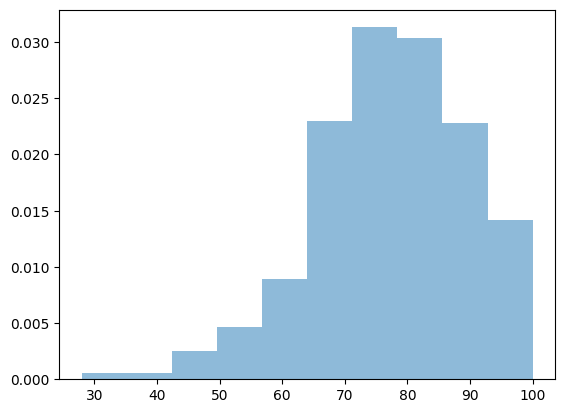

In [ ]:
## Беру для разбора, как пример, показатель - оценку Meta_score
## Посмотрим на базовую описательную статистику распределения
print(df['Meta_score'].describe(percentiles = [0.25, 0.4, 0.75, 0.99]).round(2))
# И как визуально выглядит распределение
plt.hist(df['Meta_score'], density=True, alpha=0.5)


In [ ]:
## Если нужно точечно посмотреть на что-то, то можно воспользоваться библиотекой statistics + np и pd стандарные

# Центр распределения
statistics.fmean(df['Meta_score'], weights=df['No_of_Votes']) ## среднее взвешанное
statistics.geometric_mean(df['Meta_score']) ## среднее геометрическое 
statistics.harmonic_mean(df['Meta_score']) ## среднее гармоническое (для a,b,c = 3/(1/a + 1/b + 1/c))
statistics.mode(df['Meta_score']) ## мода
statistics.multimode(df['Meta_score']) ## если мода может быть не одной

# Показатели вариации
np.var(df['Meta_score']) ## дисперсия
statistics.pvariance(df['Meta_score']) ## дисперсия общая
statistics.pstdev(df['Meta_score']) ## Стандартное отклонение общее
statistics.stdev(df['Meta_score']) ## дисперсия выборочная
statistics.variance(df['Meta_score']) ## ## Стандартное отклонение выборочное
df['Meta_score'].max() - df['Meta_score'].min() ## размах вариации
np.percentile(df['Meta_score'], 75) - np.percentile(df['Meta_score'], 25) ## межквартильный размах
df['Meta_score'].std() / df['Meta_score'].mean() *100 ## коэффициент вариации

## Показатели ассиметрии и эксцесса
df['Meta_score'].skew() ## >0 — правый хвост длиннее (положительная асимметрия).
                        ## <0 — левый хвост длиннее (отрицательная асимметрия)
df['Meta_score'].kurt() ## >0 — острый пик, тяжелые хвосты (лаптокуртическое).
                        ## <0 — плоская вершина, легкие хвосты (платикуртическое)

0.4933906620509614

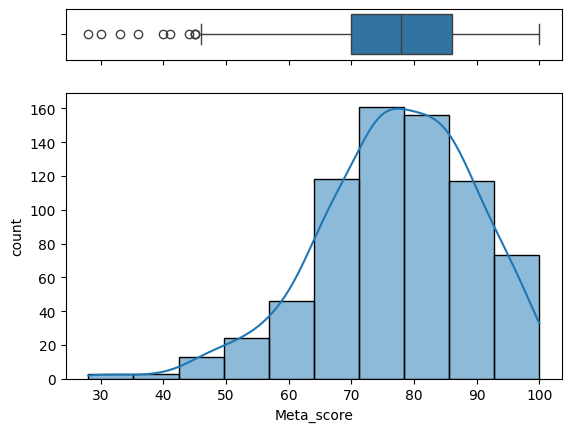

In [ ]:
## На двух графиках сразу можно посмотреть на распределение
# кроме того, укажем, что нам нужны:
fig, (ax_box, ax_hist) = plt.subplots(2, # две строки в сетке подграфиков,
                                    sharex = True, # единая шкала по оси x и
                                    gridspec_kw = {'height_ratios': (.15, .85)}) # пропорция 15/85 по высоте
 
# затем создадим графики, указав через параметр ax, в какой подграфик поместить каждый из них
sns.boxplot(x = df['Meta_score'], ax = ax_box)
sns.histplot(x = df['Meta_score'], ax = ax_hist, bins = 10, kde = True)
 
# добавим подписи к каждому из графиков через метод .set()
ax_box.set(xlabel = '') # пустые кавычки удаляют подпись (!)
ax_hist.set(xlabel = 'Meta_score')
ax_hist.set(ylabel = 'count')
 
# выведем результат
plt.show()

In [ ]:
## Можем проверить распределение на конкретную форму (см отдельно стат. тесты)
print(st.shapiro(df['Meta_score'])) ## Критерий Шапиро-Уилко - значение критерия близко к 1, распределение не нормально
print(st.anderson(df['Meta_score'], dist='expon'))

ShapiroResult(statistic=0.9775128281946716, pvalue=5.0932688462469246e-09)
AndersonResult(statistic=232.5934058222458, critical_values=array([0.921, 1.077, 1.34 , 1.605, 1.955]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=0.0, scale=77.15826330532212)
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


#### Категорийный показатель

In [ ]:
df['Genre'].describe() ## Драма встречается 58 раз
## многовато уникальных значений

count       714
unique      172
top       Drama
freq         58
Name: Genre, dtype: object

In [18]:
## Оставим только первый жанр
df['Top_Genre'] = df['Genre'].str.split(',').str[0]
df['Top_Genre'].describe()

count       714
unique       12
top       Drama
freq        192
Name: Top_Genre, dtype: object

In [ ]:
## По умолчанию фиксированный размер графиков
matplotlib.rcParams['figure.figsize'] = (20, 5)

<BarContainer object of 12 artists>

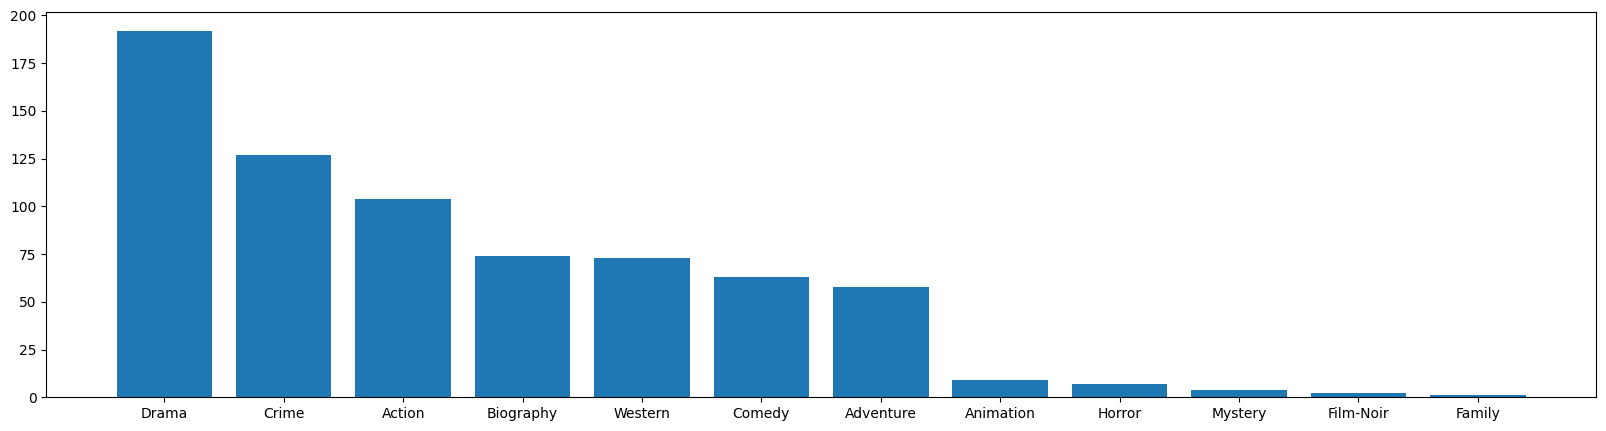

In [ ]:

plt.figure() # Создание графика
 # Создаем первую из двух областей графика и задаем текущую ось
plt.bar(df['Top_Genre'].unique(), 
        df['Top_Genre'].value_counts())

### 5. Визуализации

#### Общее

<Axes: xlabel='IMDB_Rating'>

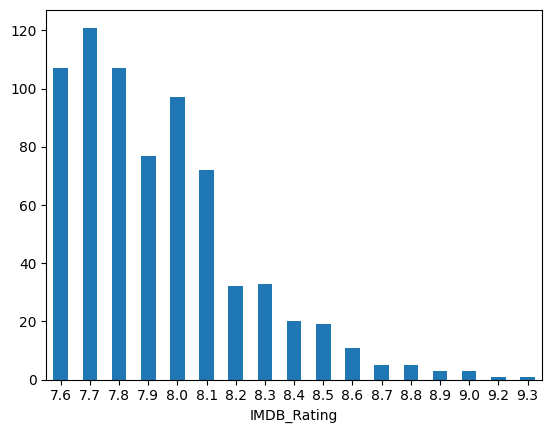

In [22]:
## Самые распространенные способы визуализации
## 1. Непосредственно через pandas
df.groupby('IMDB_Rating')['Series_Title'].count().plot.bar(rot = 0) 

<Axes: xlabel='IMDB_Rating', ylabel='count'>

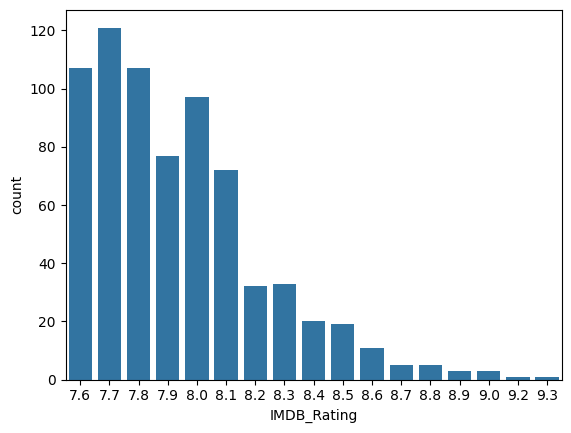

In [23]:
# 2. Распределение через sns.countplot 
sns.countplot(x = 'IMDB_Rating', data = df)


Text(0, 0.5, 'Count')

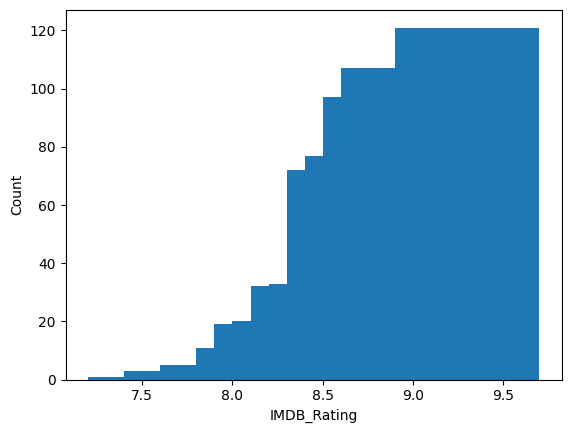

In [24]:
## 3. Через matplot с указанием уникальных значений и частоты
plt.bar(df['IMDB_Rating'].unique(), 
        df['IMDB_Rating'].value_counts())
 
plt.xlabel('IMDB_Rating')
plt.ylabel('Count')

#### Matplotlib

In [25]:
## По умолчанию фиксированный размер графиков
matplotlib.rcParams['figure.figsize']
matplotlib.rcParams['figure.figsize'] = (10, 5)

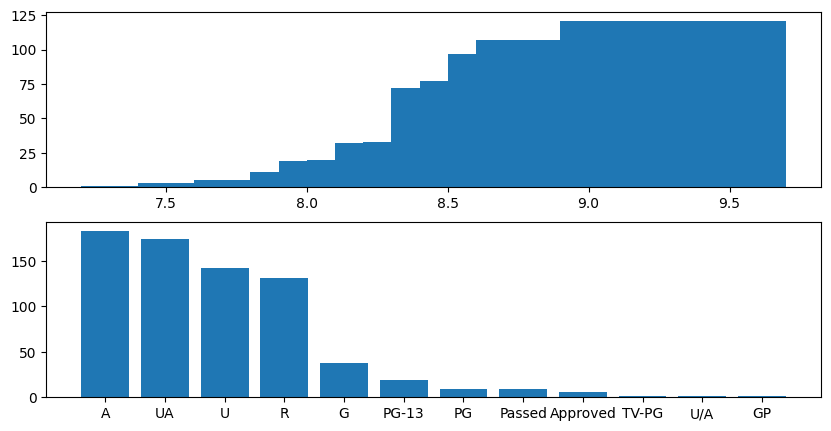

In [27]:
## В библиотеке matplot удобно создавать несколько областей с графиками
fig = plt.figure() # Создание графика
 # Создаем первую из двух областей графика и задаем текущую ось
plt.subplot(2, 1, 1) # (rows, columns, panel number)
plt.bar(df['IMDB_Rating'].unique(), 
        df['IMDB_Rating'].value_counts())
 # Создаем вторую область и задаем текущую ось
plt.subplot(2, 1, 2)
plt.bar(df['Certificate'].unique(), 
        df['Certificate'].value_counts())
## Возможность сразу сохранять изображения
fig.savefig('my_figure.png')

<BarContainer object of 12 artists>

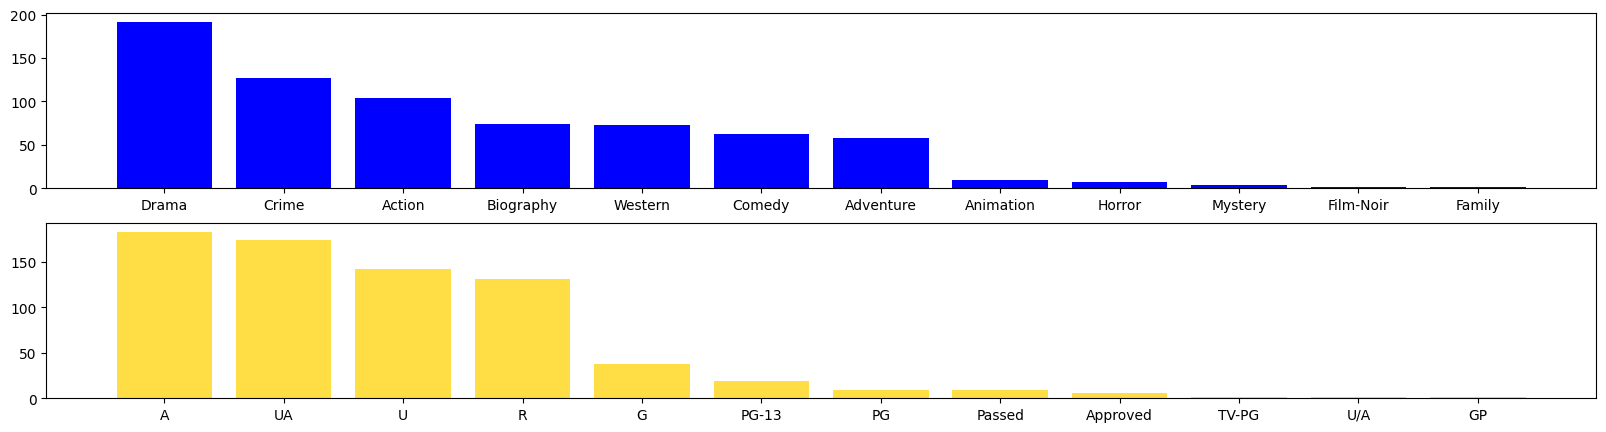

In [36]:
matplotlib.rcParams['figure.figsize'] = (20, 5)
plt.subplot(2, 1, 1) # (rows, columns, panel number)
plt.bar(df['Top_Genre'].unique(), 
        df['Top_Genre'].value_counts(), color='blue') ### возможность менять цвета через название цвета

plt.subplot(2, 1, 2)
plt.bar(df['Certificate'].unique(), 
        df['Certificate'].value_counts(), color='#FFDD44') ### возможность менять цвета через код цвета

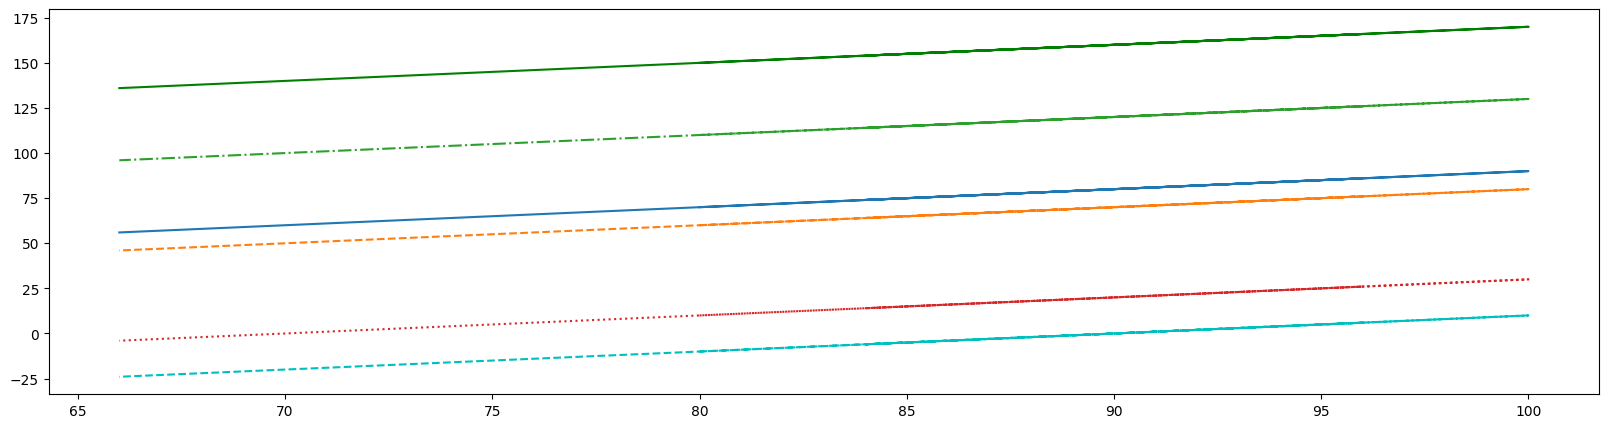

In [ ]:
## Если нужен линейный график
df_lin = df.head(10) ## для наглядности несколько точек

plt.plot(df_lin['Meta_score'], df_lin['Meta_score']-10, linestyle='solid') ## варианты отрисовки линии
plt.plot(df_lin['Meta_score'], df_lin['Meta_score']-20, linestyle='dashed')
plt.plot(df_lin['Meta_score'], df_lin['Meta_score']+30, linestyle='dashdot')
plt.plot(df_lin['Meta_score'], df_lin['Meta_score']-70, linestyle='dotted')

## возможность одновременно указать стиль и цвет
plt.plot(df_lin['Meta_score'], df_lin['Meta_score']+70, '-g') # сплошная линия зеленого цвета
plt.plot(df_lin['Meta_score'], df_lin['Meta_score']-90, '--c') # штриховая линия голубого цвета

C:\Users\n3sm3\AppData\Local\Temp\ipykernel_12932\2649628659.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


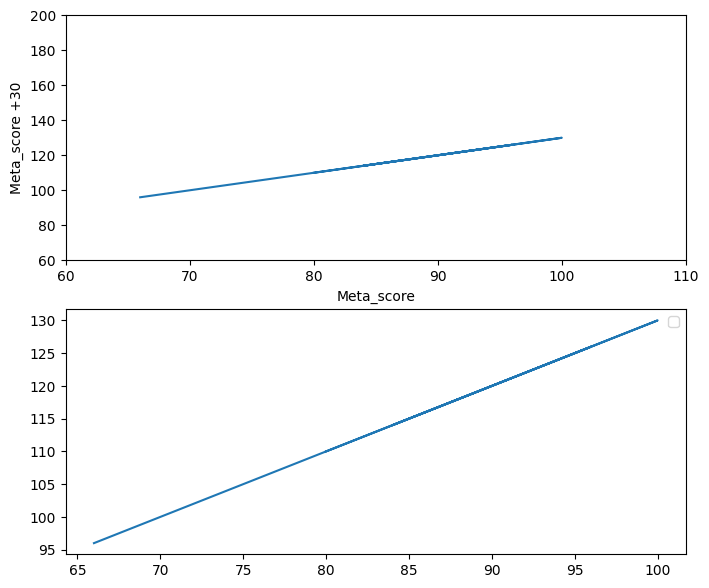

In [91]:
### Возможность менять масштаб

matplotlib.rcParams['figure.figsize'] = (8, 7)

plt.subplot(2, 1, 1) # (rows, columns, panel number)
plt.plot(df_lin['Meta_score'], df_lin['Meta_score']+30)
plt.xlim(60, 110) ## указываем сами масштаб
plt.ylim(60, 200)
plt.xlabel("Meta_score") ## Подписи для каждого графика 
plt.ylabel("Meta_score +30")
plt.subplot(2, 1, 2) # (rows, columns, panel number)
plt.plot(df_lin['Meta_score'], df_lin['Meta_score']+30)
plt.axis('tight') ## автоматический масштаб на максимуме-минимумы значений




Text(0, 0.5, 'Popular Top Genres')

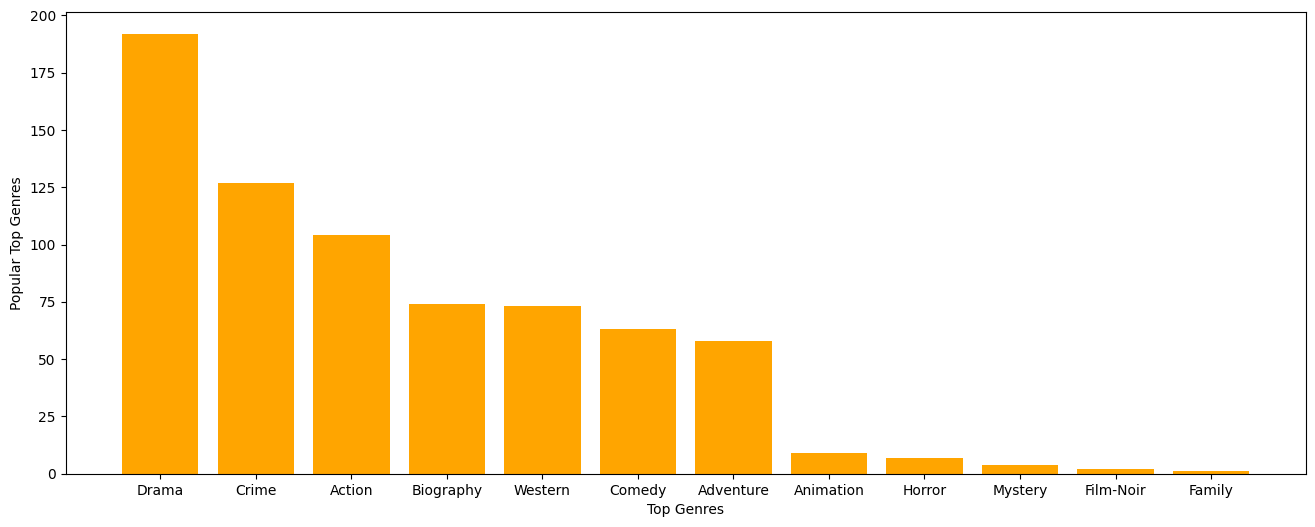

In [86]:
matplotlib.rcParams['figure.figsize'] = (16, 6)
plt.bar(df['Top_Genre'].unique(), 
        df['Top_Genre'].value_counts(), color='orange') ### возможность менять цвета через название цвета
plt.xlabel("Top Genres")
plt.ylabel("Popular Top Genres")


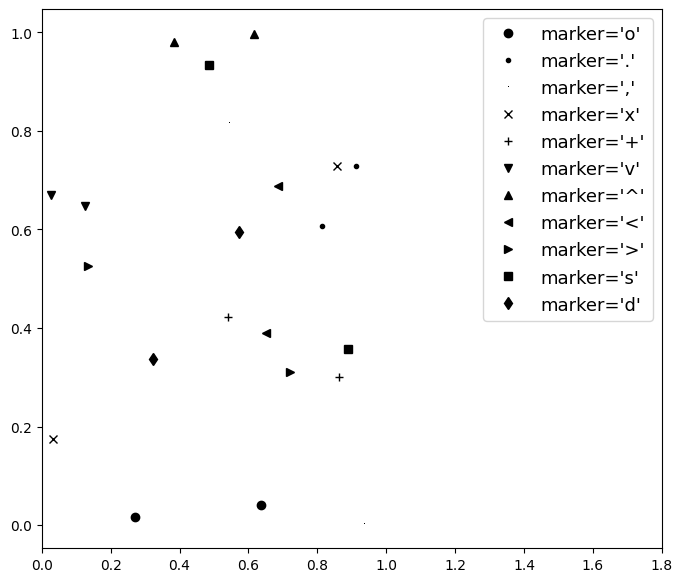

In [92]:
## Маркеры для диаграмм рассеяния
rng = np.random.default_rng(0)
for marker in ['o', '.', ',', 'x', '+', 'v', '^', '<', '>', 's', 'd']:
    plt.plot(rng.random(2), rng.random(2), marker, color='black',
    label="marker='{0}'".format(marker))
plt.legend(numpoints=1, fontsize=13)
plt.xlim(0, 1.8);

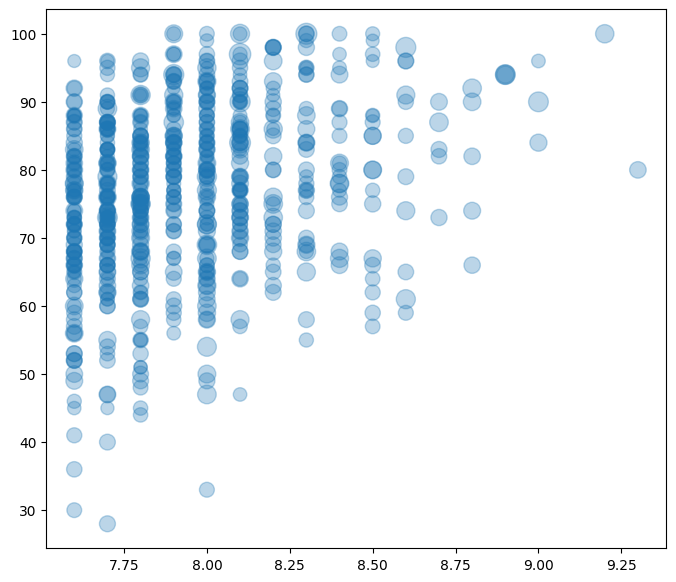

In [ ]:
plt.scatter(df['IMDB_Rating'], df['Meta_score'], s=df['Runtime'], alpha=0.3)

In [ ]:
df['Meta_score']

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Top_Genre
0,The Shawshank Redemption,1994,A,142,Drama,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469",Drama
1,The Godfather,1972,A,175,"Crime, Drama",9.2,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411",Crime
2,The Dark Knight,2008,UA,152,"Action, Crime, Drama",9.0,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444",Action
3,The Godfather: Part II,1974,A,202,"Crime, Drama",9.0,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000",Crime
4,12 Angry Men,1957,U,96,"Crime, Drama",9.0,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000",Crime
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,Giù la testa,1971,PG,157,"Drama, War, Western",7.6,77.0,Sergio Leone,Rod Steiger,James Coburn,Romolo Valli,Maria Monti,30144,"696,690",Drama
991,Kelly's Heroes,1970,GP,144,"Adventure, Comedy, War",7.6,50.0,Brian G. Hutton,Clint Eastwood,Telly Savalas,Don Rickles,Carroll O'Connor,45338,"1,378,435",Adventure
992,The Jungle Book,1967,U,78,"Animation, Adventure, Family",7.6,65.0,Wolfgang Reitherman,Phil Harris,Sebastian Cabot,Louis Prima,Bruce Reitherman,166409,"141,843,612",Animation
994,A Hard Day's Night,1964,U,87,"Comedy, Music, Musical",7.6,96.0,Richard Lester,John Lennon,Paul McCartney,George Harrison,Ringo Starr,40351,"13,780,024",Comedy


In [38]:
df['Released_Year']

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Top_Genre
0,The Shawshank Redemption,1994,A,142,Drama,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469",Drama
1,The Godfather,1972,A,175,"Crime, Drama",9.2,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411",Crime
2,The Dark Knight,2008,UA,152,"Action, Crime, Drama",9.0,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444",Action
3,The Godfather: Part II,1974,A,202,"Crime, Drama",9.0,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000",Crime
4,12 Angry Men,1957,U,96,"Crime, Drama",9.0,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000",Crime
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,Giù la testa,1971,PG,157,"Drama, War, Western",7.6,77.0,Sergio Leone,Rod Steiger,James Coburn,Romolo Valli,Maria Monti,30144,"696,690",Drama
991,Kelly's Heroes,1970,GP,144,"Adventure, Comedy, War",7.6,50.0,Brian G. Hutton,Clint Eastwood,Telly Savalas,Don Rickles,Carroll O'Connor,45338,"1,378,435",Adventure
992,The Jungle Book,1967,U,78,"Animation, Adventure, Family",7.6,65.0,Wolfgang Reitherman,Phil Harris,Sebastian Cabot,Louis Prima,Bruce Reitherman,166409,"141,843,612",Animation
994,A Hard Day's Night,1964,U,87,"Comedy, Music, Musical",7.6,96.0,Richard Lester,John Lennon,Paul McCartney,George Harrison,Ringo Starr,40351,"13,780,024",Comedy


#### Plotly Express

In [105]:
import plotly.graph_objs as go

In [110]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=x, y=x*2, name='$$f(x)=x^2$$'))
fig.add_trace(go.Scatter(x=x, y=x*9, name='$$g(x)=x$$'))
fig.show()

In [19]:
px.bar(df,
       x = 'Top_Genre',
       y = 'Meta_score',
       barmode = 'group')

   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.5 MB 2.0 MB/s eta 0:00:07
   ---------------------------------------- 0.1/12.5 MB 1.3 MB/s eta 0:00:10
   ---------------------------------------- 0.2/12.5 MB 1.3 MB/s eta 0:00:10
    --------------------------------------- 0.2/12.5 MB 1.4 MB/s eta 0:00:09
    --------------------------------------- 0.3/12.5 MB 1.3 MB/s eta 0:00:10
   - -------------------------------------- 0.3/12.5 MB 1.2 MB/s eta 0:00:10
   - -------------------------------------- 0.4/12.5 MB 1.3 MB/s eta 0:00:10
   - -------------------------------------- 0.4/12.5 MB 1.3 MB/s eta 0:00:10
   - -------------------------------------- 0.5/12.5 MB 1.3 MB/s eta 0:00:10
   - -------------------------------------- 0.6/12.5 MB 1.3 MB/s eta 0:00:10
   -- ------------------------------------- 0.7/12.5 MB 1.4 MB/s eta 0:00:09
   -- ------------------------------------- 0.8/12.5 MB 1.4 MB/s eta 0:00:09
   -- 


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\n3sm3\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
